# Binary Classification with an MLP

## Objective
This notebook builds a deep learning model for binary intrusion detection and compares its performance against a Random Forest baseline.

## Pipeline
1. Load `X_train`, `y_train`, `X_valid`, `y_valid`, `X_test`, `y_test`
2. Scale features
3. Convert arrays to PyTorch tensors
4. Build PyTorch datasets and dataloaders
5. Define and train the MLP
6. Generate validation probabilities
7. Tune the classification threshold
8. Evaluate on the test set
9. Compare results against Random Forest

In [ ]:
import sys
from pathlib import Path

In [17]:
import os
os.chdir("..")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [18]:
X_TRAIN = "data/processed/X_train.parquet"
Y_TRAIN = "data/processed/y_train.parquet"

X_VALID = "data/processed/X_valid.parquet"
Y_VALID = "data/processed/y_valid.parquet"

X_TEST = "data/processed/X_test.parquet"
Y_TEST = "data/processed/y_test.parquet"

X_train = pd.read_parquet(X_TRAIN)
y_train = pd.read_parquet(Y_TRAIN)["Label"]

X_valid = pd.read_parquet(X_VALID)
y_valid = pd.read_parquet(Y_VALID)["Label"]

X_test = pd.read_parquet(X_TEST)
y_test = pd.read_parquet(Y_TEST)["Label"]

In [19]:
y_train_binary = (y_train != "BENIGN").astype(int)
y_valid_binary = (y_valid != "BENIGN").astype(int)
y_test_binary = (y_test != "BENIGN").astype(int)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [21]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_binary.values, dtype=torch.float32).view(-1, 1)

X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid_binary.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_binary.values, dtype=torch.float32).view(-1, 1)

In [22]:
batch_size = 1024

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
class FeedforwardNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

input_dim = X_train.shape[1]
model = FeedforwardNN(input_dim).to(device)

num_neg = (y_train_binary == 0).sum()
num_pos = (y_train_binary == 1).sum()
pos_weight_value = num_neg / num_pos

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Using device: cuda


In [24]:
num_epochs = 30
patience = 3
best_valid_loss = float("inf")
epochs_without_improvement = 0

train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_valid_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            running_valid_loss += loss.item() * X_batch.size(0)

    epoch_valid_loss = running_valid_loss / len(valid_loader.dataset)
    valid_losses.append(epoch_valid_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Valid Loss: {epoch_valid_loss:.4f}")

    if epoch_valid_loss < best_valid_loss:
        best_valid_loss = epoch_valid_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "best_mlp.pt")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

# load best model AFTER training finishes
model.load_state_dict(torch.load("best_mlp.pt"))
model.eval()


Epoch 1/30 | Train Loss: 0.1164 | Valid Loss: 0.3051
Epoch 2/30 | Train Loss: 0.0603 | Valid Loss: 0.2803
Epoch 3/30 | Train Loss: 0.0551 | Valid Loss: 0.3469
Epoch 4/30 | Train Loss: 0.0559 | Valid Loss: 0.2294
Epoch 5/30 | Train Loss: 0.0535 | Valid Loss: 0.3283
Epoch 6/30 | Train Loss: 0.0521 | Valid Loss: 0.3622
Epoch 7/30 | Train Loss: 0.0520 | Valid Loss: 0.3830
Early stopping triggered.


C:\Users\Latre\AppData\Local\Temp\ipykernel_2368\2968966186.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_mlp.pt"))


FeedforwardNN(
  (network): Sequential(
    (0): Linear(in_features=78, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

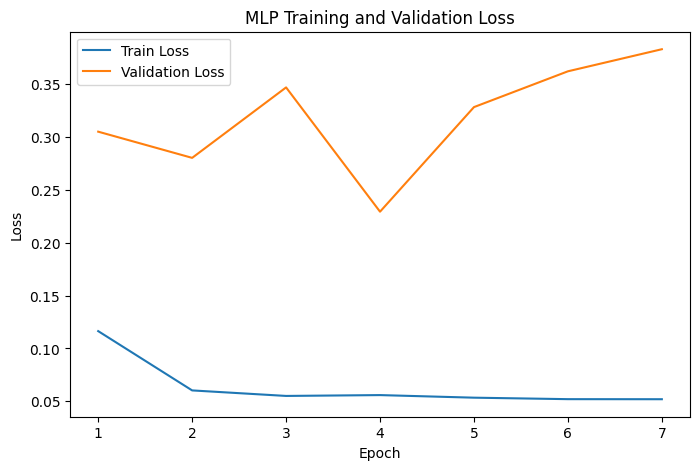

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(valid_losses) + 1), valid_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training and Validation Loss")
plt.legend()
plt.show()

In [26]:
model.eval()

valid_probs = []

with torch.no_grad():
    for X_batch, _ in valid_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits)
        valid_probs.extend(probs.cpu().numpy().flatten())

valid_probs = np.array(valid_probs)

In [27]:
threshold_results = []

for t in np.arange(0.01, 0.51, 0.01):
    valid_pred = (valid_probs >= t).astype(int)

    threshold_results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_valid_binary, valid_pred),
        "precision": precision_score(y_valid_binary, valid_pred, zero_division=0),
        "recall": recall_score(y_valid_binary, valid_pred, zero_division=0),
        "f1": f1_score(y_valid_binary, valid_pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results).sort_values("f1", ascending=False)

print(threshold_df.head(10))
best_threshold = threshold_df.iloc[0]["threshold"]
print("Best threshold:", best_threshold)


    threshold  accuracy  precision    recall        f1
6        0.07  0.981094   0.190941  0.899819  0.315033
5        0.06  0.980575   0.187155  0.903430  0.310075
4        0.05  0.980014   0.182822  0.903881  0.304130
3        0.04  0.979338   0.178077  0.906137  0.297658
2        0.03  0.978436   0.171883  0.907040  0.289001
1        0.02  0.974421   0.148608  0.907942  0.255411
0        0.01  0.970318   0.130519  0.908394  0.228244
49       0.50  0.985936   0.036356  0.074910  0.048953
48       0.49  0.985832   0.035977  0.074910  0.048609
31       0.32  0.984342   0.034328  0.082581  0.048496
Best threshold: 0.06999999999999999


In [28]:
model.eval()

test_probs = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits)
        test_probs.extend(probs.cpu().numpy().flatten())

test_probs = np.array(test_probs)
test_pred = (test_probs >= best_threshold).astype(int)

print("Confusion Matrix")
print(confusion_matrix(y_test_binary, test_pred))

print("\nClassification Report")
print(classification_report(
    y_test_binary,
    test_pred,
    target_names=["BENIGN", "ATTACK"],
    zero_division=0
))

Confusion Matrix
[[404846   9087]
 [208636  80149]]

Classification Report
              precision    recall  f1-score   support

      BENIGN       0.66      0.98      0.79    413933
      ATTACK       0.90      0.28      0.42    288785

    accuracy                           0.69    702718
   macro avg       0.78      0.63      0.61    702718
weighted avg       0.76      0.69      0.64    702718



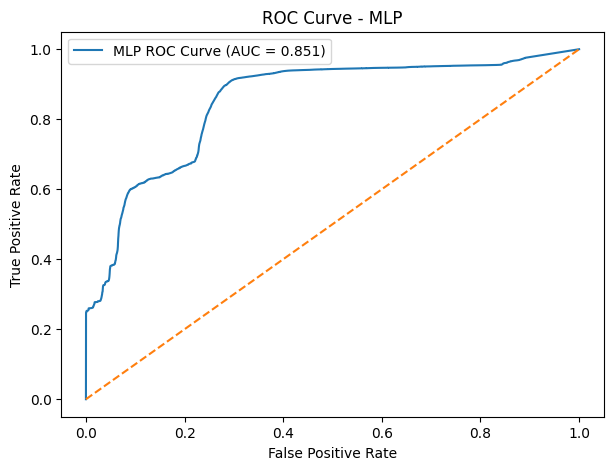

In [29]:
fpr, tpr, _ = roc_curve(y_test_binary, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"MLP ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")
plt.legend()
plt.show()

# Conclusion

### These results when comapred to random forest ML, seem negligible in comparison. As a result, we continue with the ML.